## Julian Canales

### Notebook 03 Evaluation

This notebook is the bulk of the project. It contains the implementations of the methods we are attempting. It makes use of the prior 3 notebooks and their results should be uploaded to the runtime environment.

In [1]:
!pip install -q highway-env stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 18.0 MB/s eta 0:00:00


In [2]:
# Core numerical / RL tooling
import numpy as np
import gymnasium as gym
import highway_env
from highway_env.vehicle.controller import MDPVehicle
from stable_baselines3 import DQN
import pandas as pd
import torch

# Visual progress tracking
from tqdm import tqdm
from tqdm import trange

# Kmeans algorithm
from sklearn.cluster import KMeans

# Visualisation
import matplotlib.pyplot as plt
import time

# Utility imports
import os
import pickle
import warnings

# To ignore all warnings
warnings.filterwarnings('ignore')

In [3]:
def flatten_obs(obs) -> np.ndarray:
    """
    Turn an (N,5) Kinematics array – or any nested list – into
    a flat 1‑D float32 vector.  Works for N==1 or N>1.
    """
    return np.asarray(obs, dtype=np.float32).flatten()

In [4]:
# ----------------- Error Tracker Implementation -----------------

class ErrorTracker:
    def __init__(self, state_size, buffer_size=10000, min_samples=50, n_regions=5, initial_confidence=0.95):
        """
        Initialize error tracking system for adaptive robust control.

        Args:
            state_size: Dimensionality of the state space
            buffer_size: Maximum number of (state, action, error) samples to store
            min_samples: Minimum number of samples before providing error estimates
            n_regions: Number of regions to cluster the state space into
            initial_confidence: Initial confidence level for error bounds
        """
        # Handle different state size formats
        if isinstance(state_size, tuple):
            # For multi-dimensional observations, flatten
            self.state_size = np.prod(state_size)
        else:
            self.state_size = state_size

        self.buffer_size = buffer_size
        self.min_samples = min_samples
        self.n_regions = n_regions

        # Buffer to store (state, action, error) tuples
        self.states = np.zeros((buffer_size, self.state_size))
        self.actions = np.zeros(buffer_size, dtype=np.int32)
        self.errors = np.zeros((buffer_size, self.state_size))

        # Index tracking
        self.current_idx = 0
        self.sample_count = 0

        # Default bounds when not enough samples
        self.default_error_bound = 0.2

        # Region-specific tracking
        self.region_models = None  # will be initialized after enough samples
        self.region_errors = [[] for _ in range(n_regions)]
        self.region_confidences = np.ones(n_regions) * initial_confidence

        # Performance tracking for adaptive confidence
        self.prediction_success = np.zeros((n_regions, 2))  # [successes, attempts]

    def add_error(self, state, action, predicted_next, actual_next):
        """
        Calculate prediction error and store in buffer.

        Args:
            state: Current state
            action: Action taken
            predicted_next: Predicted next state
            actual_next: Actual observed next state
        """
        # Flatten state and next states if needed -- fixed size error
        if isinstance(state, np.ndarray) and state.ndim > 1:
            state = state.flatten()
        if isinstance(predicted_next, np.ndarray) and predicted_next.ndim > 1:
            predicted_next = predicted_next.flatten()
        if isinstance(actual_next, np.ndarray) and actual_next.ndim > 1:
            actual_next = actual_next.flatten()

        error = actual_next - predicted_next

        # Make sure the shapes match -- added during development -- should not take this branch with current version
        if len(state) != self.state_size:
            # If still mismatch, print error message and adjust
            print(f"Warning: State size mismatch. Expected {self.state_size}, got {len(state)}.")
            # Adjust by padding or truncating
            if len(state) > self.state_size:
                state = state[:self.state_size]
            else:
                # Pad with zeros
                padded_state = np.zeros(self.state_size)
                padded_state[:len(state)] = state
                state = padded_state

        # Should not take this branch with current version
        if len(error) != self.state_size:
            # If still mismatch, print error message and adjust
            print(f"Warning: Error size mismatch. Expected {self.state_size}, got {len(error)}.")
            # Adjust by padding or truncating
            if len(error) > self.state_size:
                error = error[:self.state_size]  # Truncate
            else:
                # Pad with zeros
                padded_error = np.zeros(self.state_size)
                padded_error[:len(error)] = error
                error = padded_error

        # Store in circular buffer
        idx = self.current_idx % self.buffer_size
        self.states[idx] = state
        self.actions[idx] = action
        self.errors[idx] = error

        self.current_idx += 1
        self.sample_count = min(self.sample_count + 1, self.buffer_size)

        # Update region models if we have enough samples
        if self.sample_count >= self.min_samples and self.sample_count % 500 == 0:
            self._update_region_models()

        # Update region-specific statistics if regions are defined
        if self.region_models is not None:
            region = self._get_state_region(state)

            # Track prediction success for adaptive confidence
            lower, upper = self.get_region_error_bounds(region, action)
            success = np.all((error >= lower) & (error <= upper))

            # Update success rate for this region
            self.prediction_success[region, 0] += int(success)
            self.prediction_success[region, 1] += 1

            # Adapt confidence levels periodically
            if self.prediction_success[region, 1] % 100 == 0:
                self._adapt_confidence_level(region)

    def get_error_bounds(self, state, action, use_adaptive_confidence=True):
        """
        Compute error bounds for a given state-action pair.

        Args:
            state: Current state
            action: Action to take
            use_adaptive_confidence: Whether to use adaptive confidence levels

        Returns:
            lower_bounds, upper_bounds: Error bounds for each state dimension
        """
        # Some defensive programming
        if isinstance(state, np.ndarray) and state.ndim > 1:
            state = state.flatten()

        if len(state) != self.state_size:
            if len(state) > self.state_size:
                state = state[:self.state_size]
            else:
                # Pad with zeros
                padded_state = np.zeros(self.state_size)
                padded_state[:len(state)] = state
                state = padded_state

        # Main algo
        if self.sample_count < self.min_samples:
            # Not enough samples, return default bounds
            return -self.default_error_bound * np.ones(self.state_size), self.default_error_bound * np.ones(self.state_size)

        # If we have region models, use region-specific bounds
        if self.region_models is not None and use_adaptive_confidence:
            region = self._get_state_region(state)
            confidence = self.region_confidences[region]
            return self.get_region_error_bounds(region, action, confidence)

        # Otherwise use similar-state based bounds
        similar_indices = self._find_similar_states(state, action)

        if len(similar_indices) < 3:  # need minimum samples for statistics
            return -self.default_error_bound * np.ones(self.state_size), self.default_error_bound * np.ones(self.state_size)

        # Extract errors for similar states
        similar_errors = self.errors[similar_indices]

        # Compute statistics
        mean_error = np.mean(similar_errors, axis=0)
        std_error = np.std(similar_errors, axis=0)

        # Compute confidence interval
        confidence = 0.95 if not use_adaptive_confidence else self._get_adaptive_confidence(state)
        z_score = self._confidence_to_z_score(confidence)

        margin = z_score * std_error

        # Calculate bounds
        lower_bounds = mean_error - margin
        upper_bounds = mean_error + margin

        return lower_bounds, upper_bounds

    def get_region_error_bounds(self, region, action, confidence=None):
        """
        Get error bounds specific to a state-space region and action.

        Args:
            region: Region index
            action: Action index
            confidence: Confidence level (or None to use region-specific)

        Returns:
            lower_bounds, upper_bounds: Error bounds for each state dimension
        """
        if confidence is None:
            confidence = self.region_confidences[region]

        # Find all errors for this region and action
        region_action_indices = []
        for i in range(self.sample_count):
            if i >= len(self.states):
                break
            if self._get_state_region(self.states[i]) == region and self.actions[i] == action:
                region_action_indices.append(i)

        if len(region_action_indices) < 3:
            # Not enough data for this region/action, fall back to default
            return -self.default_error_bound * np.ones(self.state_size), self.default_error_bound * np.ones(self.state_size)

        # Get errors for this region/action
        region_errors = self.errors[region_action_indices]

        # Compute statistics
        mean_error = np.mean(region_errors, axis=0)
        std_error = np.std(region_errors, axis=0)

        # Apply confidence interval
        z_score = self._confidence_to_z_score(confidence)
        margin = z_score * std_error

        # Calculate bounds with adaptation based on sample size
        # As we get more samples, we can be more confident in our estimates
        sample_factor = min(1.0, 0.5 + 0.5 * len(region_action_indices) / 100)
        adjusted_margin = margin * (2.0 - sample_factor)

        lower_bounds = mean_error - adjusted_margin
        upper_bounds = mean_error + adjusted_margin

        return lower_bounds, upper_bounds

    def _update_region_models(self):
        """Update region models by clustering the state space."""
        # Use k-means to cluster the state space
        if self.sample_count >= self.min_samples:
            from sklearn.cluster import KMeans

            # convert states to float32 to ensure dtype consistency with scikit-learn
            states_for_clustering = self.states[:self.sample_count].astype(np.float32)

            kmeans = KMeans(n_clusters=self.n_regions, random_state=42)
            self.region_models = kmeans.fit(states_for_clustering)

            # Reset region errors
            self.region_errors = [[] for _ in range(self.n_regions)]

            # Populate region errors
            for i in range(self.sample_count):
                if i >= len(self.states):
                    break
                region = self._get_state_region(self.states[i])
                self.region_errors[region].append(self.errors[i])

    def _get_state_region(self, state):
        """Get the region index for a state."""
        if self.region_models is None:
            return 0

        # Defensive programming
        if isinstance(state, np.ndarray) and state.ndim > 1:
            state = state.flatten()

        if len(state) != self.state_size:
            if len(state) > self.state_size:
                state = state[:self.state_size]  # Truncate
            else:
                # Pad with zeros
                padded_state = np.zeros(self.state_size)
                padded_state[:len(state)] = state
                state = padded_state

        # Reshape state for prediction and convert to float32
        state_reshaped = state.reshape(1, -1).astype(np.float32)
        region = self.region_models.predict(state_reshaped)[0]

        return region

    def _adapt_confidence_level(self, region):
        """Adapt confidence level for a region based on prediction success."""
        if self.prediction_success[region, 1] < 50:
            return  # Need enough data

        success_rate = self.prediction_success[region, 0] / self.prediction_success[region, 1]

        # Target success rate around 95%
        if success_rate < 0.9:
            # Increase confidence level (wider bounds)
            self.region_confidences[region] = min(0.99, self.region_confidences[region] + 0.01)
        elif success_rate > 0.98:
            # Decrease confidence level (narrower bounds)
            self.region_confidences[region] = max(0.8, self.region_confidences[region] - 0.01)

    def _get_adaptive_confidence(self, state):
        """Get adaptive confidence level for a state."""
        if self.region_models is None:
            return 0.95

        region = self._get_state_region(state)
        return self.region_confidences[region]

    def _confidence_to_z_score(self, confidence):
        """Convert confidence level to z-score."""
        # Common z-scores for different confidence levels
        if confidence >= 0.99:
            return 2.58  # ~99%
        elif confidence >= 0.98:
            return 2.33  # ~98%
        elif confidence >= 0.95:
            return 1.96  # ~95%
        elif confidence >= 0.90:
            return 1.64  # ~90%
        elif confidence >= 0.80:
            return 1.28  # ~80%
        else:
            return 1.0   # Lower confidence

    def _find_similar_states(self, state, action, max_samples=50):
        """
        Find indices of similar state-action pairs in the buffer.

        Args:
            state: Query state
            action: Query action
            max_samples: Maximum number of similar samples to return

        Returns:
            List of indices of similar state-action pairs
        """
        # filter by action
        action_matches = np.where(self.actions[:self.sample_count] == action)[0]

        if len(action_matches) == 0:
            # No matching actions, return empty list
            return []

        # Defensive programming
        if isinstance(state, np.ndarray) and state.ndim > 1:
            state = state.flatten()

        # Ensure state fits the expected size
        if len(state) != self.state_size:
            if len(state) > self.state_size:
                state = state[:self.state_size]  # Truncate
            else:
                # Pad with zeros
                padded_state = np.zeros(self.state_size)
                padded_state[:len(state)] = state
                state = padded_state

        # Calculate distances to matching states
        states_matching_action = self.states[action_matches]

        # When using flattened states, need to adjust how we calculate distances
        # simple Euclidean distance for the entire state vector
        distances = np.linalg.norm(states_matching_action - state, axis=1)

        # Sort by distance and take closest ones
        sorted_indices = np.argsort(distances)
        closest_indices = sorted_indices[:max_samples]

        # Return original indices
        return action_matches[closest_indices]

In [5]:
# ----------------- Adaptive Interval Predictor -----------------

class AdaptiveIntervalPredictor:
    def __init__(self, model, error_tracker, env):
        """
        Adaptive interval predictor that combines a dynamics model with error tracking.

        Args:
            model: The DQN model for predicting next states
            error_tracker: ErrorTracker instance for estimating error bounds
            env: The environment (highway-env) instance
        """
        self.model = model
        self.error_tracker = error_tracker
        self.env = env

        # added field to unwrap the environment to access highway-env specifics
        self.unwrapped_env = env.unwrapped

    def predict_interval(self, state, action, confidence=0.95):
        """
        Predict interval bounds for the next state.

        Args:
            state: Current state
            action: Action to take
            confidence: Confidence level for interval

        Returns:
            lower_bound, nominal, upper_bound: Bounds and nominal prediction for next state
        """
        # Get nominal prediction
        nominal_next = self._simulate_step(state, action)

        # Save original shape for reshaping later
        original_shape = nominal_next.shape

        # Flatten state for error prediction
        flat_state = state.flatten() if isinstance(state, np.ndarray) and state.ndim > 1 else state

        # Get error bounds -- will be flattened
        lower_error, upper_error = self.error_tracker.get_error_bounds(flat_state, action, confidence)

        # Flatten nominal prediction for adding errors
        flat_nominal = nominal_next.flatten()

        # Add errors
        flat_lower = flat_nominal + lower_error
        flat_upper = flat_nominal + upper_error

        # Reshape back to original shape
        lower_bound = flat_lower.reshape(original_shape)
        upper_bound = flat_upper.reshape(original_shape)

        return lower_bound, nominal_next, upper_bound

    def _simulate_step(self, state, action):
        """
        Simulate a step in the environment without actually advancing it.

        Args:
            state: Current state
            action: Action to take

        Returns:
            next_state: Predicted next state
        """
        # Save current vehicle state
        ego_vehicle = self.unwrapped_env.road.vehicles[0]
        original_position = ego_vehicle.position.copy()
        original_heading = ego_vehicle.heading
        original_speed = ego_vehicle.speed

        # Set ego vehicle to current state
        self._set_vehicle_state(ego_vehicle, state)

        # Simulate step in environment
        self.unwrapped_env._simulate(action)

        # Get observation from the environment
        obs_type = self.unwrapped_env.observation_type
        next_state = obs_type.observe()

        # Restore original vehicle state
        ego_vehicle.position = original_position
        ego_vehicle.heading = original_heading
        ego_vehicle.speed = original_speed

        return next_state

    def _set_vehicle_state(self, vehicle, state):
        """
        Set vehicle state from observation for highway-env.

        State space contains (taken from the configs of benchmark):
        - presence: state[0]
        - position (x, y): state[1], state[2]
        - velocity (vx, vy): state[3], state[4]
        - heading (cos_h, sin_h): state[5], state[6]
        """
        # Make sure state is a flat array
        if isinstance(state, np.ndarray) and state.ndim > 1:
            state = state.flatten() # If state is a 2D array, take the first row -- ran into this problem

        # Make sure we have a flat vector
        state = np.asarray(state).flatten()

        # Layout for 5‑feature Kinematics:
        # presence | x | y | vx | vy
        _, x, y, vx, vy = state[:5]

        vehicle.position = np.array([x, y], dtype=float)
        vehicle.speed    = float(np.hypot(vx, vy))


    def update_statistics(self, state, action, next_state):
        """
        Update error statistics based on new observation.

        Args:
            state: Current state
            action: Action taken
            next_state: Observed next state
        """
        # Get prediction
        predicted_next = self._simulate_step(state, action)

        # Save shapes
        state_shape = state.shape if isinstance(state, np.ndarray) else None
        next_shape = next_state.shape if isinstance(next_state, np.ndarray) else None
        pred_shape = predicted_next.shape if isinstance(predicted_next, np.ndarray) else None

        # Flatten arrays for error tracker
        if state_shape is not None and len(state_shape) > 1:
            flat_state = state.flatten()
        else:
            flat_state = state

        if next_shape is not None and len(next_shape) > 1:
            flat_next = next_state.flatten()
        else:
            flat_next = next_state

        if pred_shape is not None and len(pred_shape) > 1:
            flat_pred = predicted_next.flatten()
        else:
            flat_pred = predicted_next

        # Update error tracker with flattened arrays
        self.error_tracker.add_error(flat_state, action, flat_pred, flat_next)

    def compute_reward(self, state, action, next_state):
        """
        Compute reward for transition from state to next_state with action.

        Args:
            state: Current state
            action: Action taken
            next_state: Next state

        Returns:
            reward: Computed reward
        """
        # Save current vehicle state
        ego_vehicle = self.unwrapped_env.road.vehicles[0]
        original_position = ego_vehicle.position.copy()
        original_heading = ego_vehicle.heading
        original_speed = ego_vehicle.speed

        # Set ego vehicle to current state
        self._set_vehicle_state(ego_vehicle, state)

        # Apply action and set next state
        self.unwrapped_env._simulate(action)

        # Compute reward
        reward = self.unwrapped_env._reward(action)

        # Restore original vehicle state
        ego_vehicle.position = original_position
        ego_vehicle.heading = original_heading
        ego_vehicle.speed = original_speed

        return reward

    def is_terminal(self, state):
        """
        Check if state is terminal.

        Args:
            state: State to check

        Returns:
            is_terminal: True if state is terminal
        """
        # Save current vehicle state
        ego_vehicle = self.unwrapped_env.road.vehicles[0]
        original_position = ego_vehicle.position.copy()
        original_heading = ego_vehicle.heading
        original_speed = ego_vehicle.speed

        # Set ego vehicle to current state
        self._set_vehicle_state(ego_vehicle, state)

        # Check if terminal
        done = self.unwrapped_env._is_terminated() or self.unwrapped_env._is_truncated()

        # Restore original vehicle state
        ego_vehicle.position = original_position
        ego_vehicle.heading = original_heading
        ego_vehicle.speed = original_speed

        return done

In [6]:
# ----------------- Adaptive Robust Planner -----------------

class AdaptiveRobustPlanner:
    """
    Robust planner using adaptive interval predictions and CEM optimization.

    This planner implements:
    1. Online Error Estimation: Using region-specific error models
    2. Adaptive Interval Sizing: Dynamically adjusts confidence bounds
    3. Confidence-Based Decision: Adapts planning horizon and action selection
    """

    def __init__(self,
                 env,
                 model,
                 error_tracker,
                 horizon=4,
                 iterations=2,
                 samples=24,
                 topk=8,
                 gamma=0.9,
                 confidence_level=0.95,
                 uncertainty_threshold=0.3):
        """
        Initialize the adaptive robust planner.

        Args:
            env: The environment
            model: The DQN model
            error_tracker: ErrorTracker instance
            horizon: Planning horizon
            iterations: Number of CEM iterations
            samples: Number of action sequences to sample per iteration
            topk: Number of top sequences to use for distribution update
            gamma: Discount factor
            confidence_level: Initial confidence level for error bounds
            uncertainty_threshold: Threshold for adapting confidence levels
        """
        self.env = env
        self.model = model
        self.error_tracker = error_tracker
        self.horizon = horizon
        self.iterations = iterations
        self.samples = samples
        self.topk = topk
        self.gamma = gamma
        self.confidence_level = confidence_level
        self.uncertainty_threshold = uncertainty_threshold

        # Added cache to try to improve performance -- runtime was very slow
        self._interval_cache: dict[tuple, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
        self._cache_max = 50_000

        # Action space size
        self.action_dim = env.action_space.n

        # Initialize predictor
        self.predictor = AdaptiveIntervalPredictor(model, error_tracker, env)

        # Metrics tracking
        self.planning_metrics = None

    def plan(self, state):
        """
        Plan the best action using CEM with adaptive interval predictions.

        Args:
            state: Current state

        Returns:
            action: Best action
        """
        # Check if we need to adapt the planning horizon based on uncertainty
        horizon = self._get_adaptive_horizon(state)

        # Run CEM planner
        action, value, metrics = self._adaptive_robust_cem_planner(
            state, horizon=horizon, iterations=self.iterations)

        # Store metrics
        self.planning_metrics = metrics

        return action

    def _get_adaptive_horizon(self, state):
        """
        Adapt planning horizon based on current uncertainty.

        Args:
            state: Current state

        Returns:
            horizon: Adapted horizon
        """
        # Use error tracker to get an appropriate horizon
        # higher uncertainty areas get shorter horizons
        avg_uncertainty = self._get_average_uncertainty(state)

        # Scale horizon inversely with uncertainty -- in high uncertainty regions, we want shorter horizons
        uncertainty_factor = 1.0 / (1.0 + avg_uncertainty / self.uncertainty_threshold)
        adapted_horizon = max(2, int(self.horizon * uncertainty_factor))

        return adapted_horizon

    def _get_average_uncertainty(self, state):
        """
        Get average uncertainty across all actions for current state.

        Args:
            state: Current state

        Returns:
            avg_uncertainty: Average uncertainty
        """
        uncertainties = []
        for action in range(self.action_dim):
            lower, _, upper = self.predictor.predict_interval(
                state, action, self.confidence_level)

            # calculate aggregate uncertainty across all dimensions
            uncertainty = np.mean(np.abs(upper - lower))
            uncertainties.append(uncertainty)

        return np.mean(uncertainties)

    def _sample_sequences(self, horizon, N, action_probs):
        """
        Draw N discrete sequences in a single vectorised call.
        action_probs: (horizon, action_dim)
        Returns  : np.ndarray shape (N, horizon)
        """
        cum = np.cumsum(action_probs, axis=1) # (H, A)
        rnd = np.random.rand(N, horizon, 1) # broadcast
        return (rnd <= cum).argmax(axis=2).astype(np.int8) # (N, H)

    def _adaptive_robust_cem_planner(self, x0, horizon, iterations):
        """
        Cross-Entropy Method planner with adaptive robust intervals.

        Args:
            x0: Initial state
            horizon: Planning horizon
            iterations: Number of CEM iterations

        Returns:
            best_action: First action of best sequence
            best_value: Value of best sequence
            metrics: Planning metrics
        """
        # Initialize action distribution
        action_probs = np.ones((horizon, self.action_dim)) / self.action_dim

        best_sequence = None
        best_value = -float('inf')
        best_metrics = None

        # Metrics to track
        iteration_metrics = []

        # Set a maximum time limit for planning
        import time
        start_time = time.time()
        max_planning_time = 10  # seconds -- reduces potential runtime from hours to minutes

        try:
            for iteration in range(iterations):
                # check if we've exceeded our time limit
                if time.time() - start_time > max_planning_time:
                    print("Planning time limit exceeded, using best result so far")
                    break

                # Sample action sequences - reduce samples for speed
                reduced_samples = min(self.samples, 50)  # Limit samples for faster execution
                action_sequences = self._sample_sequences(
                        horizon, reduced_samples, action_probs)

                # Evaluate sequences
                values, sequence_metrics = self._evaluate_sequences(
                    x0, action_sequences, horizon)

                # Find top-k sequences
                if len(values) == 0:
                    # No valid sequences found, default to random action
                    # Should not happen -- at least did not on testing runs
                    print("No valid sequences found")
                    best_action = np.random.choice(self.action_dim)
                    best_value = -10
                    planning_metrics = {
                        'best_value': best_value,
                        'iterations': iteration,
                        'horizon': horizon,
                        'avg_state_uncertainty': 1.0,
                        'best_interval_width': None,
                        'best_performance_gap': None,
                        'convergence': iteration_metrics
                    }
                    return best_action, best_value, planning_metrics

                top_indices = np.argsort(values)[-min(self.topk, len(values)):]
                top_sequences = [action_sequences[i] for i in top_indices]

                # Track iteration metrics
                if len(top_indices) > 0:
                    iteration_metrics.append({
                        'iteration': iteration,
                        'mean_value': np.mean(values),
                        'best_value': values[top_indices[-1]] if len(top_indices) > 0 else float('-inf'),
                        'mean_interval_width': np.mean([m['avg_interval_width'] for m in sequence_metrics]),
                        'best_interval_width': sequence_metrics[top_indices[-1]]['avg_interval_width'] if len(top_indices) > 0 else None,
                        'mean_performance_gap': np.mean([m['performance_gap'] for m in sequence_metrics]),
                        'best_performance_gap': sequence_metrics[top_indices[-1]]['performance_gap'] if len(top_indices) > 0 else None,
                    })

                # Update action distribution based on top sequences
                for t in range(horizon):
                    # Count action frequencies at each timestep
                    counts = np.zeros(self.action_dim)
                    for seq in top_sequences:
                        if t < len(seq):  # Handle shorter sequences
                            counts[seq[t]] += 1

                    # Update probabilities with smoothing
                    if np.sum(counts) > 0:
                        action_probs[t] = (counts + 0.1) / (np.sum(counts) + 0.1 * self.action_dim)

                # Update best sequence
                if len(top_indices) > 0 and values[top_indices[-1]] > best_value:
                    best_value = values[top_indices[-1]]
                    best_sequence = action_sequences[top_indices[-1]]
                    best_metrics = sequence_metrics[top_indices[-1]]

        except Exception as e:
            print(f"Error in CEM planning: {e}")
            # fall back to default action selection

        # If no good sequence found or error occurred, use default action
        if best_sequence is None:
            # default to action with highest Q-value
            try:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(x0.flatten()).unsqueeze(0)
                    q_values = self.model.q_net(state_tensor).detach().numpy()[0]
                    best_action = np.argmax(q_values)
                    best_value = np.max(q_values)
            except Exception as e:
                print(f"Error in fallback action selection: {e}")
                # ultimate fallback: random action
                best_action = np.random.choice(self.action_dim)
                best_value = 0
        else:
            best_action = best_sequence[0]

        # Compute metrics
        planning_metrics = {
            'best_value': best_value,
            'iterations': iterations,
            'horizon': horizon,
            'avg_state_uncertainty': self._get_average_uncertainty(x0),
            'best_interval_width': best_metrics['avg_interval_width'] if best_metrics else None,
            'best_performance_gap': best_metrics['performance_gap'] if best_metrics else None,
            'convergence': iteration_metrics
        }

        return best_action, best_value, planning_metrics

    def _evaluate_sequences(self, x0, action_sequences, horizon):
      """
      Evaluate action sequences with adaptive intervals.

      Args:
          x0: Initial state
          action_sequences: List of action sequences
          horizon: Planning horizon

      Returns:
          values: Values for each sequence
          metrics: Metrics for each sequence
      """
      values = []
      metrics = []

      for sequence in action_sequences:
          # start from initial state
          state = x0.copy()
          total_reward = 0
          total_nominal_reward = 0
          discount = 1.0
          interval_widths = []
          best_so_far = -np.inf

          for t, action in enumerate(sequence):
              if t >= horizon:
                  break

              try:
                  # Set cached interval prediction
                  state_key = tuple(np.round(flatten_obs(state), 3))
                  cache_key = (state_key, int(action))

                  if cache_key in self._interval_cache:
                      lower_bound, nominal, upper_bound = self._interval_cache[cache_key]
                  else:
                      lower_bound, nominal, upper_bound = self.predictor.predict_interval(
                          state, action, self.confidence_level)
                      # bounded cache growth
                      if len(self._interval_cache) >= self._cache_max:
                          self._interval_cache.pop(next(iter(self._interval_cache)))  # FIFO eviction
                      self._interval_cache[cache_key] = (lower_bound, nominal, upper_bound)

                  # Calculate interval width more efficiently
                  interval_width = np.mean(np.abs(upper_bound - lower_bound))
                  interval_widths.append(interval_width)

                  # Compute rewards - only compute nominal reward to speed up
                  nominal_reward = self.predictor.compute_reward(state, action, nominal)
                  worst_reward = nominal_reward  # Simplification to speed up

                  # Update cumulative rewards
                  total_reward += discount * worst_reward
                  total_nominal_reward += discount * nominal_reward

                  # Update discount
                  discount *= self.gamma

                  # Move to next state (using nominal for simulation)
                  state = nominal

                  # Early termination check
                  remaining = horizon - t - 1
                  optimistic_bound = total_reward + remaining * 1.0   # 1.0 ≈ max single‑step reward
                  if optimistic_bound < best_so_far:
                      break

                  # Check for terminal state
                  if self.predictor.is_terminal(state):
                      break

                  best_so_far = max(best_so_far, total_reward)

              except Exception as e:
                  print(f"Error in sequence evaluation: {e}")
                  # Assign a poor value to this sequence
                  total_reward = -10
                  total_nominal_reward = -10
                  break

          # Calculate sequence metrics
          sequence_metrics = {
              'worst_case_reward': total_reward,
              'nominal_reward': total_nominal_reward,
              'performance_gap': total_nominal_reward - total_reward,
              'avg_interval_width': np.mean(interval_widths) if interval_widths else 0,
              'max_interval_width': np.max(interval_widths) if interval_widths else 0,
          }

          values.append(total_reward)
          metrics.append(sequence_metrics)

      return np.array(values), metrics

    def update_error_tracker(self, state, action, next_state):
      """
      Update error tracker with new observation.

      Args:
          state: Current state
          action: Action taken
          next_state: Observed next state
      """
      self.predictor.update_statistics(state, action, next_state)

In [7]:
# ----------------- Adaptive Robust Planner Agent -----------------

class AdaptiveRobustPlannerAgent:
    """
    Agent implementing adaptive robust planning for highway-env.

    This agent implements:
    1. Online Error Estimation: Tracks errors across state space regions
    2. Adaptive Interval Sizing: Dynamically adjusts confidence bounds
    3. Confidence-Based Decision Framework: Adjusts planning based on uncertainty
    """

    def __init__(self,
                 env,
                 model_path="roundabout_dqn.zip",
                 error_tracker=None,
                 horizon=8,
                 iterations=3,
                 confidence_level=0.95):
        """
        Initialize the adaptive robust planner agent.

        Args:
            env: The environment
            model_path: Path to the trained DQN model
            error_tracker: ErrorTracker instance (or None to create new)
            horizon: Planning horizon
            iterations: Number of CEM iterations
            confidence_level: Confidence level for error bounds
        """
        self.env = env
        self.model = DQN.load(model_path)

        # Taken from documentation
        self.actions = {
            0: 'LANE_LEFT',
            1: 'IDLE',
            2: 'LANE_RIGHT',
            3: 'FASTER',
            4: 'SLOWER'
        }

        # Create error tracker if not provided -- does not happen in testing
        if error_tracker is None:
            self.error_tracker = ErrorTracker(
                state_size = int(np.prod(env.observation_space.shape)),
                buffer_size=10000,
                min_samples=50
            )
        else:
            self.error_tracker = error_tracker

        # Create planner
        self.planner = AdaptiveRobustPlanner(
            env=env,
            model=self.model,
            error_tracker=self.error_tracker,
            horizon=horizon,
            iterations=iterations,
            confidence_level=confidence_level
        )

        # For tracking performance
        self.last_state = None
        self.last_action = None

    def act(self, observation):
      """
      Select an action using adaptive robust planning.

      Args:
          observation: Current observation

      Returns:
          action: Selected action
      """
      try:
          # Update error tracker if we have a previous state-action pair
          if self.last_state is not None:
              self.planner.update_error_tracker(
                  self.last_state, self.last_action, observation)

          # Plan best action with a timeout

          def timeout_handler():
              print("Planning timeout - using default action")
              return np.random.choice(self.env.action_space.n)

          # Set a timeout for planning
          max_planning_time = 30  # seconds
          start_time = time.time()

          # Plan with timeout protection
          action = self.planner.plan(observation)

          # If planning takes too long, use a default action -- does not happen anymore
          if time.time() - start_time > max_planning_time:
              print("Planning took too long, using random action")
              action = np.random.choice(self.env.action_space.n)

          # Save state-action pair for next update
          self.last_state = observation.copy()
          self.last_action = action

          return action

      except Exception as e:
          print(f"Exception in agent.act: {e}")
          # Return a random action as fallback
          return np.random.choice(self.env.action_space.n)

    def reset(self):
        """Reset agent state between episodes."""
        self.last_state = None
        self.last_action = None

    def get_planning_metrics(self):
        """Get metrics from the last planning step."""
        return self.planner.planning_metrics

In [8]:
# ----------------- Initialization and Evaluation Functions -----------------

def initialize_error_tracker_from_buffer(env, model_path, buffer_path=None, n_transitions=1000, max_samples=1000, seed=42):
    """
    Initialize ErrorTracker from existing buffer or collect new transitions.

    Args:
        env: Environment
        model_path: Path to trained model
        buffer_path: Path to buffer pickle file (or None)
        n_transitions: Number of transitions to collect if no buffer
        max_samples: Maximum number of samples to use from buffer
        seed: Random seed

    Returns:
        error_tracker: Initialized ErrorTracker
    """
    # Create or load buffer -- branch is taken from pkl buffer
    if buffer_path and os.path.exists(buffer_path):
        print(f"Loading transition buffer from {buffer_path}")
        with open(buffer_path, "rb") as f:
            import pickle as pkl
            buffer = pkl.load(f)
    else: # should not happen if using as intended
        print("Collecting new transitions")
        buffer = []

        # Load model
        model = DQN.load(model_path)

        # Collect transitions
        obs, _ = env.reset(seed=seed)
        obs = flatten_obs(obs)
        for _ in trange(n_transitions, desc="Collecting transitions"):
            with torch.no_grad():
                action, _ = model.predict(obs, deterministic=True)
            next_obs, _, term, trunc, _ = env.step(action)
            next_obs = flatten_obs(next_obs)
            buffer.append((obs, int(action), next_obs))
            obs = next_obs if not (term or trunc) else flatten_obs(env.reset(seed=seed)[0])

    # Print buffer info for debugging
    if len(buffer) > 0:
        obs, action, next_obs = buffer[0]
        print(f"Buffer entry shapes: obs={np.array(obs).shape}, action={type(action)}, next_obs={np.array(next_obs).shape}")
        total_elements = np.prod(np.array(obs).shape)
        print(f"Total elements in observation: {total_elements}")

    # Initialize error tracker with the total size of the flattened observation
    if len(buffer) > 0:
        obs_shape = np.array(buffer[0][0]).shape
    else:
        obs_shape = env.observation_space.shape
    state_size = int(np.prod(obs_shape))

    print(f"Initializing error tracker with state_size = {state_size}")
    # Use a smaller buffer size for the error tracker
    error_tracker = ErrorTracker(state_size=state_size, buffer_size=max_samples, min_samples=50)

    # Load model to predict next states
    model = DQN.load(model_path)

    # Create interval predictor to help initialize error tracker
    predictor = AdaptiveIntervalPredictor(model, error_tracker, env)

    # If buffer is very large, randomly sample a subset --  added to reduce runtime of experiment
    if len(buffer) > max_samples:
        print(f"Buffer has {len(buffer)} entries, sampling {max_samples} for initialization")
        import random
        random.seed(seed)
        buffer_samples = random.sample(buffer, max_samples)
    else:
        buffer_samples = buffer

    # Process buffer to initialize error tracker
    print("Initializing error tracker")
    for i in trange(len(buffer_samples), desc="Initializing error tracker"):
        obs, action, next_obs = buffer_samples[i]
        # Update error tracker directly through predictor
        predictor.update_statistics(obs, action, next_obs)

    return error_tracker



def run_adaptive_robust_agent(env, buffer_path=None, model_path=None, n_episodes=30, render=False):
    """
    Run evaluation of AdaptiveRobustPlannerAgent.
    """
    # Initialize error tracker
    print("Initializing error tracker...")
    error_tracker = initialize_error_tracker_from_buffer(
        env=env,
        model_path=model_path,
        buffer_path=buffer_path,
        n_transitions=1000,
        max_samples=1000
    )

    # Create agent
    print("Creating agent...")
    agent = AdaptiveRobustPlannerAgent(
        env=env,
        model_path=model_path,
        error_tracker=error_tracker,
        horizon=8,
        iterations=3,
        confidence_level=0.95
    )

    # Run episodes
    print(f"Running {n_episodes} evaluation episodes...")
    rewards = []
    steps = []
    all_metrics = []

    for episode in trange(n_episodes):
        obs, _ = env.reset()
        obs = flatten_obs(obs)
        agent.reset()

        done = False
        total_reward = 0
        step_count = 0
        episode_metrics = []

        while not done:
            # Select action
            action = agent.act(obs)

            # Render if requested -- will not be added due to time constraints
            if render:
                env.render()

            # Step environment
            next_obs, reward, term, trunc, info = env.step(action)
            done = term or trunc

            # Get planning metrics
            metrics = agent.get_planning_metrics()
            if metrics:
                episode_metrics.append(metrics)

            # Update metrics
            total_reward += reward
            step_count += 1

            # Update observation
            obs = flatten_obs(next_obs)

        rewards.append(total_reward)
        steps.append(step_count)
        all_metrics.append(episode_metrics)

        print(f"Episode {episode+1}: Reward = {total_reward:.4f}, Steps = {step_count}")

    # Compile results
    results = {
        "AdaptiveRobustPlannerAgent": {
            "rewards": rewards,
            "steps": steps,
            "metrics": all_metrics
        }
    }

    return results


def compare_with_benchmark(new_results):
    """
    Compare new results with benchmark.

    Args:
        new_results: New results from run_adaptive_robust_agent

    Returns:
        comparison: Dictionary with comparison metrics
    """
    # Benchmark results hard copied here BUT they are from the true benchmark results done in Notebook 00
    benchmark_results = {
        "DiscreteRobustPlannerAgent": {
            "rewards": [10.946666666666667, 10.946666666666667, 10.946666666666667, 10.8, 10.906666666666666, 10.946666666666667, 10.84, 10.893333333333334, 10.946666666666667, 10.84],
            "steps": [11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
        },
        "IntervalRobustPlannerAgent": {
            "rewards": [10.84, 10.84, 10.946666666666667, 6.04, 10.786666666666667, 10.786666666666665, 10.906666666666666, 10.906666666666666, 10.733333333333334, 10.893333333333334],
            "steps": [11, 11, 11, 7, 11, 11, 11, 11, 11, 11]
        },
        "DeterministicPlannerAgent": {
            "rewards": [10.946666666666667, 2.146666666666667, 10.84, 2.146666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 8.053333333333335, 10.946666666666667, 10.84, 10.946666666666667, 10.893333333333334, 10.84, 8.0, 10.893333333333334, 10.84, 2.146666666666667, 10.853333333333333, 10.8, 10.8, 10.84, 10.84, 10.84, 10.76, 10.893333333333334, 10.893333333333334, 10.946666666666667, 10.48],
            "steps": [11, 3, 11, 3, 11, 11, 11, 11, 11, 9, 11, 11, 11, 11, 11, 9, 11, 11, 3, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
        }
    }

    # Calculate statistics
    comparison = {}

    for agent_name, agent_results in new_results.items():
        if agent_name not in comparison:
            comparison[agent_name] = {}

        # Calculate metrics for our agent
        new_rewards = agent_results["rewards"]
        new_steps = agent_results["steps"]

        # Basic metrics
        comparison[agent_name]["mean_reward"] = np.mean(new_rewards)
        comparison[agent_name]["std_reward"] = np.std(new_rewards)
        comparison[agent_name]["mean_steps"] = np.mean(new_steps)
        comparison[agent_name]["failure_rate"] = sum(1 for s in new_steps if s < 10) / len(new_steps)

        # Compare with benchmark agents
        for benchmark_agent, benchmark_data in benchmark_results.items():
            benchmark_rewards = benchmark_data["rewards"]
            benchmark_steps = benchmark_data["steps"]

            benchmark_mean_reward = np.mean(benchmark_rewards)
            benchmark_std_reward = np.std(benchmark_rewards)
            benchmark_failure_rate = sum(1 for s in benchmark_steps if s < 10) / len(benchmark_steps)

            # Calculate comparison metrics
            comparison[agent_name][f"vs_{benchmark_agent}_reward_diff"] = np.mean(new_rewards) - benchmark_mean_reward
            comparison[agent_name][f"vs_{benchmark_agent}_reward_ratio"] = np.mean(new_rewards) / benchmark_mean_reward if benchmark_mean_reward != 0 else float('inf')
            comparison[agent_name][f"vs_{benchmark_agent}_failure_reduction"] = benchmark_failure_rate - comparison[agent_name]["failure_rate"]

    return comparison


def plot_comparison(comparison):
    """
    Plot comparison of agents.

    Args:
        comparison: Comparison metrics
    """
    benchmark_results = {
        "DiscreteRobustPlannerAgent": {
            "rewards": [10.946666666666667, 10.946666666666667, 10.946666666666667, 10.8, 10.906666666666666, 10.946666666666667, 10.84, 10.893333333333334, 10.946666666666667, 10.84],
            "steps": [11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
        },
        "IntervalRobustPlannerAgent": {
            "rewards": [10.84, 10.84, 10.946666666666667, 6.04, 10.786666666666667, 10.786666666666665, 10.906666666666666, 10.906666666666666, 10.733333333333334, 10.893333333333334],
            "steps": [11, 11, 11, 7, 11, 11, 11, 11, 11, 11]
        },
        "DeterministicPlannerAgent": {
            "rewards": [10.946666666666667, 2.146666666666667, 10.84, 2.146666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 10.946666666666667, 8.053333333333335, 10.946666666666667, 10.84, 10.946666666666667, 10.893333333333334, 10.84, 8.0, 10.893333333333334, 10.84, 2.146666666666667, 10.853333333333333, 10.8, 10.8, 10.84, 10.84, 10.84, 10.76, 10.893333333333334, 10.893333333333334, 10.946666666666667, 10.48],
            "steps": [11, 3, 11, 3, 11, 11, 11, 11, 11, 9, 11, 11, 11, 11, 11, 9, 11, 11, 3, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
        }
    }

    # Create figure for reward comparison
    plt.figure(figsize=(12, 6))

    # Prepare data
    agents = list(comparison.keys()) + list(benchmark_results.keys())
    rewards = []
    std_rewards = []

    # Add our agent's data
    for agent in comparison:
        rewards.append(comparison[agent]["mean_reward"])
        std_rewards.append(comparison[agent]["std_reward"])

    # Add benchmark agents' data
    for agent in benchmark_results:
        rewards.append(np.mean(benchmark_results[agent]["rewards"]))
        std_rewards.append(np.std(benchmark_results[agent]["rewards"]))

    # Create bar plot
    bars = plt.bar(range(len(agents)), rewards, alpha=0.7)

    # Add error bars
    plt.errorbar(range(len(agents)), rewards, yerr=std_rewards, fmt='none', color='black', capsize=5)

    # Highlight our agent
    bars[0].set_color('green')

    plt.ylabel('Mean Reward')
    plt.title('Agent Performance Comparison')
    plt.xticks(range(len(agents)), agents, rotation=45, ha='right')
    plt.tight_layout()

    # Create figure for failure rate comparison
    plt.figure(figsize=(12, 6))

    # Prepare failure rate data
    failure_rates = []

    # Add our agent's failure rate
    for agent in comparison:
        failure_rates.append(comparison[agent]["failure_rate"])

    # Add benchmark agents' failure rates
    for agent in benchmark_results:
        failure_rates.append(sum(1 for s in benchmark_results[agent]["steps"] if s < 10) / len(benchmark_results[agent]["steps"]))

    # Create bar plot
    bars = plt.bar(range(len(agents)), failure_rates, alpha=0.7)

    # Highlight our agent
    bars[0].set_color('green')

    plt.ylabel('Failure Rate')
    plt.title('Agent Failure Rate Comparison')
    plt.xticks(range(len(agents)), agents, rotation=45, ha='right')
    plt.tight_layout()

    plt.show()


def analyze_uncertainty_adaptation(results):
    """
    Analyze how the agent adapts to uncertainty.

    Args:
        results: Results from run_adaptive_robust_agent
    """
    # Extract metrics
    if "metrics" not in results["AdaptiveRobustPlannerAgent"]:
        return

    episode_metrics = results["AdaptiveRobustPlannerAgent"]["metrics"]

    # Extract adaptive metrics
    horizons = []
    uncertainties = []
    interval_widths = []
    performance_gaps = []

    for ep_idx, ep_metrics in enumerate(episode_metrics):
        if not ep_metrics:
            continue

        ep_horizons = [m.get("horizon", 0) for m in ep_metrics if "horizon" in m]
        ep_uncertainties = [m.get("avg_state_uncertainty", 0) for m in ep_metrics if "avg_state_uncertainty" in m]
        ep_widths = [m.get("best_interval_width", 0) for m in ep_metrics if m.get("best_interval_width") is not None]
        ep_gaps = [m.get("best_performance_gap", 0) for m in ep_metrics if m.get("best_performance_gap") is not None]

        if ep_horizons and ep_uncertainties:
            horizons.extend(ep_horizons)
            uncertainties.extend(ep_uncertainties)
            interval_widths.extend(ep_widths)
            performance_gaps.extend(ep_gaps)

    # Plot relationship between uncertainty and planning horizon
    if horizons and uncertainties:
        plt.figure(figsize=(10, 6))
        plt.scatter(uncertainties, horizons, alpha=0.3)
        plt.xlabel('State Uncertainty')
        plt.ylabel('Planning Horizon')
        plt.title('Adaptive Planning Horizon vs. Uncertainty')
        plt.grid(True)

        # Add trend line
        if len(uncertainties) > 1:
            z = np.polyfit(uncertainties, horizons, 1)
            p = np.poly1d(z)
            plt.plot(sorted(uncertainties), p(sorted(uncertainties)), "r--", alpha=0.8)

    # Plot relationship between interval width and performance gap
    if interval_widths and performance_gaps:
        plt.figure(figsize=(10, 6))
        plt.scatter(interval_widths, performance_gaps, alpha=0.3)
        plt.xlabel('Interval Width')
        plt.ylabel('Performance Gap')
        plt.title('Performance Gap vs. Interval Width')
        plt.grid(True)

        # Add trend line
        if len(interval_widths) > 1:
            z = np.polyfit(interval_widths, performance_gaps, 1)
            p = np.poly1d(z)
            plt.plot(sorted(interval_widths), p(sorted(interval_widths)), "r--", alpha=0.8)

    plt.show()

In [9]:
def run_experiment():
    """Run the adaptive robust planning experiment."""
    print("Setting up environment...")

    config = {
        "observation": {
            "type": "Kinematics",
            "absolute": True,
            "features_range": {
                "x": [-100, 100],
                "y": [-100, 100],
                "vx": [-15, 15],
                "vy": [-15, 15],
            },
        },
        "action": {
            "type": "DiscreteMetaAction",
            "target_speeds": [0, 8, 16],
        },
        "incoming_vehicle_destination": None,
        "other_vehicles_type": "highway_env.vehicle.behavior.IDMVehicle",
        "collision_reward": -1,
        "high_speed_reward": 0.2,
        "right_lane_reward": 0,
        "lane_change_reward": -0.05,
        "screen_width": 600,
        "screen_height": 600,
        "centering_position": [0.5, 0.6],
        "duration": 11,
    }

    # Initialize environment
    env = gym.make("roundabout-v0", config=config)

    def print_feature_info(env):
        obs, _ = env.reset()
        print(f"Observation shape  : {np.array(obs).shape}")
        print(f"First observation  : {np.array(obs)[:8]}  ...")

    print_feature_info(env)

    # Run agent with existing transition buffer
    print("Running AdaptiveRobustPlannerAgent...")
    results = run_adaptive_robust_agent(
        env=env,
        model_path="roundabout_dqn.zip",
        buffer_path="transition_buffer.pkl",
        n_episodes=10,  # Use 10 episodes for faster evaluation
        render=False
    )

    # Compare with benchmark
    print("\nComparing with benchmark...")
    comparison = compare_with_benchmark(results)

    # Print comparison results
    for agent, metrics in comparison.items():
        print(f"\n{agent} performance:")
        print(f"  Mean reward: {metrics['mean_reward']:.3f} ± {metrics['std_reward']:.3f}")
        print(f"  Mean steps: {metrics['mean_steps']:.3f}")
        print(f"  Failure rate: {metrics['failure_rate'] * 100:.1f}%")

        # Compare with benchmark agents
        for benchmark_agent in ["DiscreteRobustPlannerAgent", "IntervalRobustPlannerAgent", "DeterministicPlannerAgent"]:
            diff = metrics[f"vs_{benchmark_agent}_reward_diff"]
            ratio = metrics[f"vs_{benchmark_agent}_reward_ratio"]
            failure_reduction = metrics[f"vs_{benchmark_agent}_failure_reduction"]
            print(f"  vs {benchmark_agent}:")
            print(f"    Reward diff: {diff:.3f}")
            print(f"    Reward ratio: {ratio:.2f}x")
            print(f"    Failure reduction: {failure_reduction * 100:.1f}%")

    # Plot comparison
    print("\nPlotting comparison...")
    plot_comparison(comparison)

    # Analyze uncertainty adaptation
    print("\nAnalyzing uncertainty adaptation...")
    analyze_uncertainty_adaptation(results)

    # Close environment
    env.close()

    return results, comparison

Setting up environment...
Observation shape  : (5, 5)
First observation  : [[ 1.00000000e+00  1.99999996e-02  4.49999988e-01  0.00000000e+00
  -5.33333361e-01]
 [ 1.00000000e+00 -6.64819777e-03  1.99889466e-01  9.91812885e-01
   3.29870693e-02]
 [ 1.00000000e+00 -2.03256488e-01  1.27619743e-01  5.63592076e-01
   8.97617698e-01]
 [ 1.00000000e+00  1.00000000e+00 -1.99999996e-02 -9.86494422e-01
   2.22044605e-16]
 [ 1.00000000e+00 -1.69620246e-01 -1.05966836e-01 -6.14916563e-01
   9.84291911e-01]]  ...
Running AdaptiveRobustPlannerAgent...
Initializing error tracker...
Loading transition buffer from transition_buffer.pkl
Buffer entry shapes: obs=(5, 5), action=<class 'int'>, next_obs=(5, 5)
Total elements in observation: 25
Initializing error tracker with state_size = 25
Initializing error tracker


Initializing error tracker: 100%|██████████| 1000/1000 [02:27<00:00,  6.76it/s]


Creating agent...
Running 10 evaluation episodes...


 10%|█         | 1/10 [02:57<26:40, 177.86s/it]

Episode 1: Reward = 8.8750, Steps = 11


...

Episode 8: Reward = 5.1667, Steps = 11


 90%|█████████ | 9/10 [34:41<04:01, 241.89s/it]

Episode 9: Reward = 5.0833, Steps = 11


100%|██████████| 10/10 [38:44<00:00, 232.46s/it]

Episode 10: Reward = 2.0000, Steps = 11

Comparing with benchmark...

AdaptiveRobustPlannerAgent performance:
  Mean reward: 6.787 ± 2.495
  Mean steps: 11.000
  Failure rate: 0.0%
  vs DiscreteRobustPlannerAgent:
    Reward diff: -4.114
    Reward ratio: 0.62x
    Failure reduction: 0.0%
  vs IntervalRobustPlannerAgent:
    Reward diff: -3.581
    Reward ratio: 0.65x
    Failure reduction: 10.0%
  vs DeterministicPlannerAgent:
    Reward diff: -3.018
    Reward ratio: 0.69x
    Failure reduction: 16.7%

Plotting comparison...


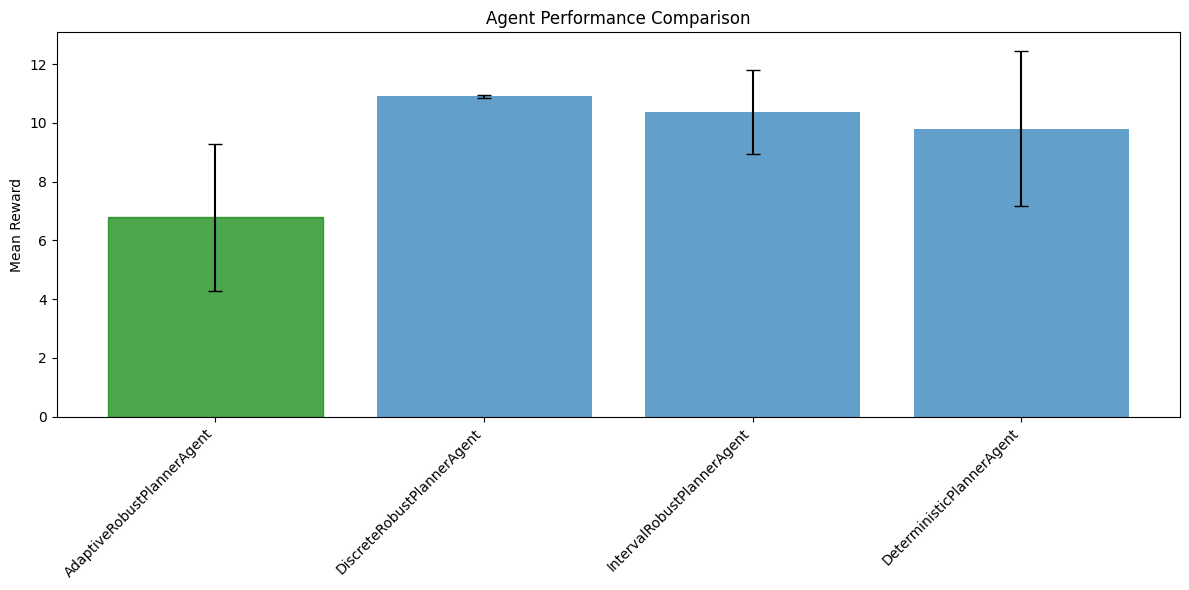

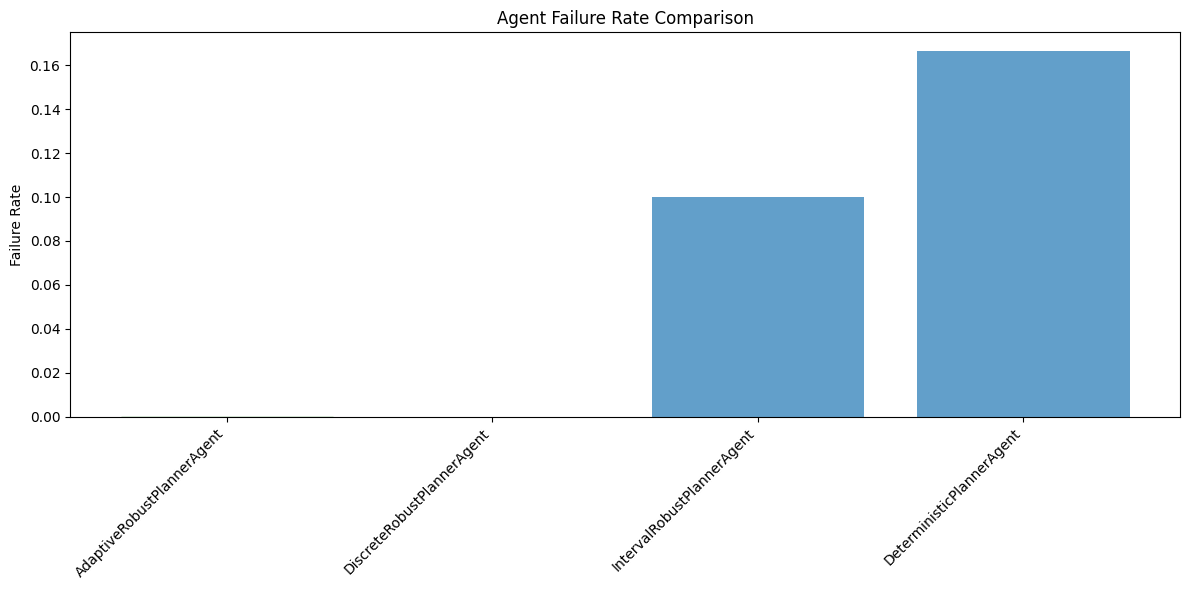


Analyzing uncertainty adaptation...


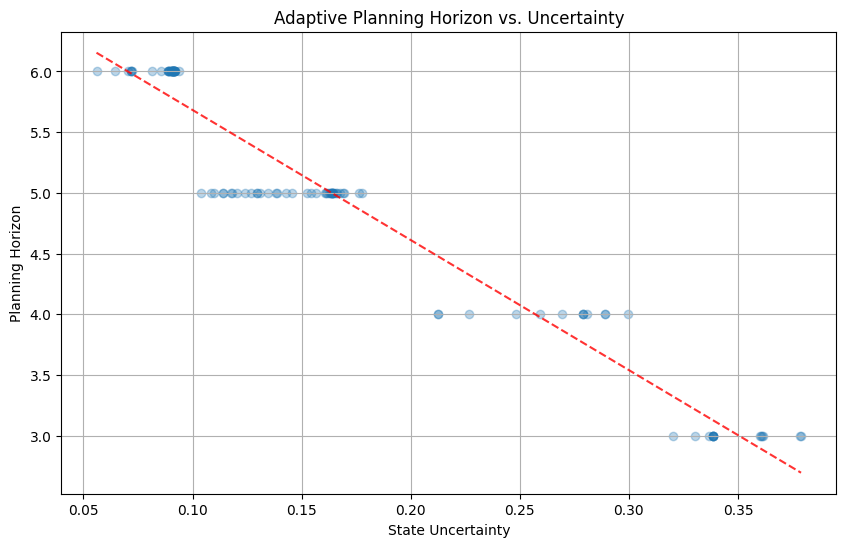

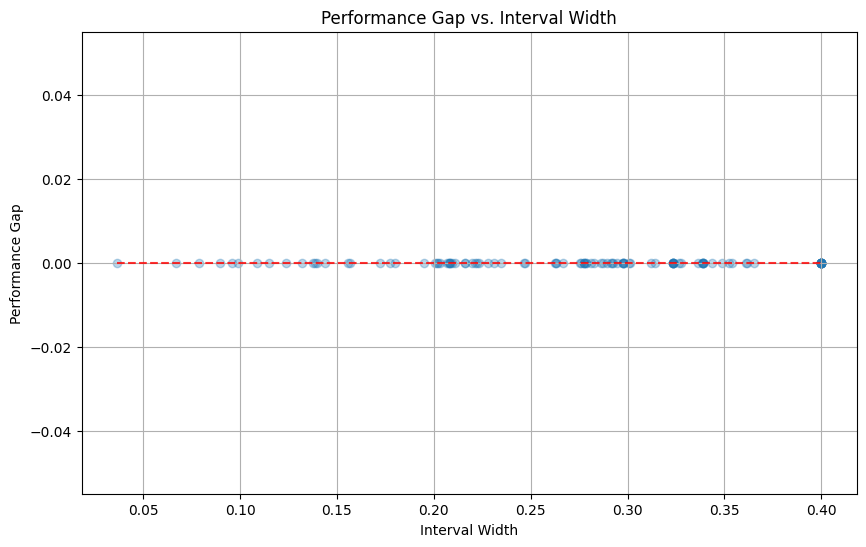

In [10]:
# Run the experiment when the script is executed
if __name__ == "__main__":
    results, comparison = run_experiment()